   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                18      0  
4                18      0  

 

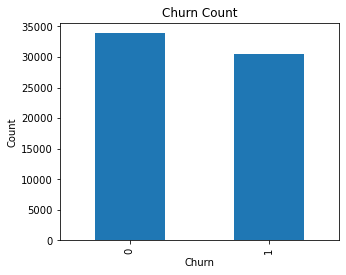

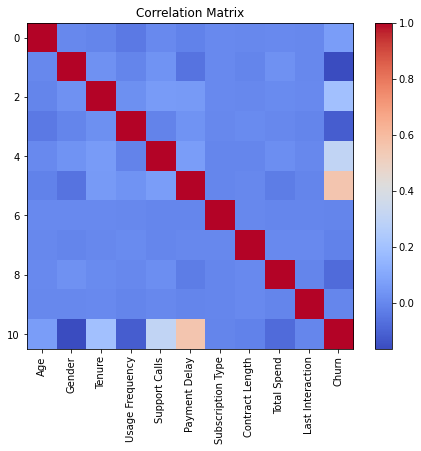

Scaled Features:
[[-1.43420211e+00 -9.34824837e-01 -4.09099642e-01 -1.22525528e-01
  -4.49806835e-01  1.11453793e+00 -1.22518771e+00  1.10461570e-02
   2.18407687e-01 -7.52323771e-01]
 [-6.97303985e-02 -9.34824837e-01 -2.33641563e-01  1.46542392e+00
   5.13590330e-01 -4.67000127e-01  1.22324795e+00  1.10461570e-02
   1.64741682e-01  5.21064734e-01]
 [ 3.61155405e-01  1.06971912e+00 -2.92127590e-01 -5.76225369e-01
  -1.09207161e+00  1.34047194e+00 -9.69880844e-04 -1.22347696e+00
   8.27900169e-01  6.36827325e-01]
 [-5.00616202e-01  1.06971912e+00 -1.34487606e+00 -3.49375448e-01
  -1.28674447e-01 -1.51321104e-02 -9.69880844e-04  1.24556927e+00
  -1.18457501e+00  2.89539551e-01]
 [ 7.92041209e-01 -9.34824837e-01  1.52093923e+00  1.01172408e+00
   1.15585511e+00 -1.70963717e+00  1.22324795e+00 -1.22347696e+00
  -3.07559068e-02  2.89539551e-01]]
Training Samples: 51499
Testing Samples: 12875
Training Completed Successfully.
Predicted Values:
[0 0 1 ... 1 0 0]

Accuracy= 0.8306019417475728



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

df=pd.read_csv(r"D:\customer_churn_dataset-testing-master.csv")
print(df.head())

print("\n Shape of the dataset")
print(df.shape)

print("\n Column names:")
print(df.columns)

print("\n Information of the column")
print(df.info())

print("\nStatical summary")
print(df.describe())


df.drop('CustomerID',axis=1,inplace=True)

encoder=LabelEncoder()
df["Gender"]=encoder.fit_transform(df["Gender"])
df["Subscription Type"]=encoder.fit_transform(df["Subscription Type"])
df["Contract Length"]=encoder.fit_transform(df["Contract Length"])
print(df.head())


print("\n================EDA==================\n")
print(df['Churn'].value_counts())

plt.figure(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(df.corr(),cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(df.columns)),df.columns,rotation=90)
plt.xticks(range(len(df.columns)),df.columns)

plt.title("Correlation Matrix")
plt.show()


X=df.drop("Churn",axis=1)
y=df["Churn"]

scaler=StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Features:")
print(X_scaled[:5])

X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.20,random_state=42)

print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))



model=LogisticRegression()


model.fit(X_train,y_train)
print("Training Completed Successfully.")
#TEST THE MODEL

y_pred=model.predict(X_test)
print("Predicted Values:")
print(y_pred)
#EVALUATE THE MODEL

accuracy=accuracy_score(y_test,y_pred)
print("\nAccuracy=",accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))


print("\nClassification Report")
print(classification_report(y_test,y_pred))


new_customer = [[
    24,     # Age
    1,      # Gender (1 = Male)
    3,      # Tenure (months)
    2,      # Usage Frequency
    8,      # Support Calls
    15,     # Payment Delay (days)
    0,      # Subscription Type (Basic)
    0,      # Contract Length (Monthly)
    180.50, # Total Spend
    5       # Last Interaction (days ago)
]]
                
new_scaled=scaler.transform(new_customer)
   
prediction = model.predict(new_scaled)
                
if prediction[0]==1:   
    print("CUSTOMER WILL CHURN")
else:
    print("CUSTOMER WILL NOT CHURN")
    
accuracy=accuracy_score(y_test,y_pred)
print("\nAccuracy=",accuracy)
                
print("\n============MACHINE LEARNING PIPELINE COMPLETED===============\n")